In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

In [3]:
np.random.seed(42)

days = 365

temperature = np.random.normal(30, 5, days)  # avg temp 30°C
rainfall = np.random.choice([0, 1], size=days, p=[0.8, 0.2])  # 1 = rainy
is_weekend = np.random.choice([0, 1], size=days, p=[0.7, 0.3])

# Lunch crowd logic
cafeteria_load = (
    200 
    + (temperature * 5)
    - (rainfall * 50)
    - (is_weekend * 40)
    + np.random.normal(0, 10, days)
)

data = pd.DataFrame({
    'Temperature': temperature,
    'Rainfall': rainfall,
    'Weekend': is_weekend,
    'Cafeteria_Load': cafeteria_load
})

data.head()

,Temperature,Rainfall,Weekend,Cafeteria_Load
0,32.483571,0,0,358.405649
1,29.308678,1,0,290.954174
2,33.238443,0,0,369.964332
3,37.615149,1,1,313.730987
4,28.829233,0,0,343.488663


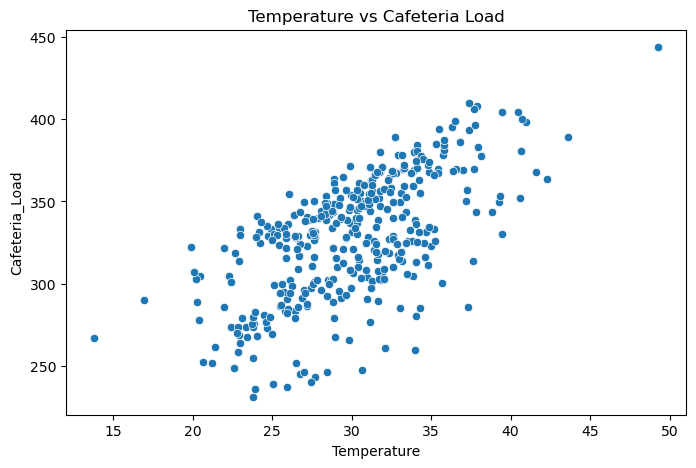

In [4]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Temperature', y='Cafeteria_Load', data=data)
plt.title("Temperature vs Cafeteria Load")
plt.show()

In [5]:
X = data[['Temperature', 'Rainfall', 'Weekend']]
y = data['Cafeteria_Load']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [7]:
y_pred = model.predict(X_test)

In [8]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2 Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)
print("Accuracy (%):", r2 * 100)

R2 Score: 0.9453525607878709
MAE: 7.064596825591283
RMSE: 9.006714164952282
Accuracy (%): 94.53525607878709


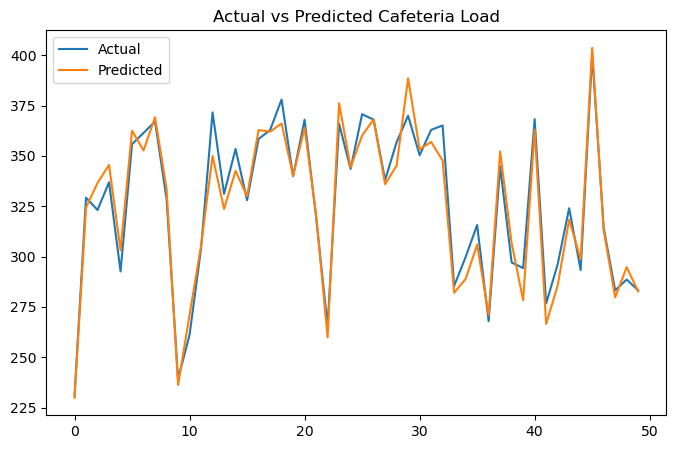

In [9]:
plt.figure(figsize=(8,5))
plt.plot(y_test.values[:50], label='Actual')
plt.plot(y_pred[:50], label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Cafeteria Load")
plt.show()

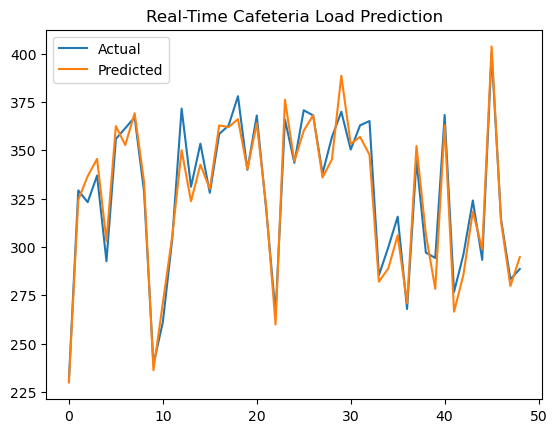

In [10]:
import time
from IPython.display import clear_output

plt.figure()

for i in range(1, 50):
    clear_output(wait=True)
    plt.plot(y_test.values[:i], label="Actual")
    plt.plot(y_pred[:i], label="Predicted")
    plt.legend()
    plt.title("Real-Time Cafeteria Load Prediction")
    plt.pause(0.3)

plt.show()